In [18]:
%matplotlib inline
import os
import sys
# import re
# from glob import glob
# from collections import defaultdict
# import warnings
import joblib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import nibabel as nib
from nilearn import plotting
import rsatoolbox as rsa
# import copy
# Extend sys.path to import project modules
sys.path.append('/home/reabt/experiments/ncc/MRI/code/')
from utils.load_cfg import load_config_instance
from utils.compile import compile_SL_rdms_files
from nilearn.image import new_img_like
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [19]:
def plot_stuff(config_class_name, subjectID, min = True, max = True):
    """
    Plot the RDM brain and the max/min voxel overlay.
    """
    cfg = load_config_instance(config_class_name, subjectID)
    cfg.print_summary()
    outFiles = cfg.get_outFile_names()
    mask = nib.load(cfg.maskFile)
    SL_rdms = joblib.load(outFiles['SL_rdms'])
    RDM_brain = joblib.load(outFiles['RDM_brain'])
    eval_results = joblib.load(outFiles['eval_results'])
    eval_score = [float(e.evaluations.item()) for e in eval_results]
    
    # # Plot RDM brain
    # fig, ax = plt.subplots(figsize=(10, 10))
    # plotting.plot_stat_map(
    #     new_img_like(mask, RDM_brain), 
    #     title=f'RDM Brain: {cfg.subjectID}', 
    #     colorbar=True, 
    #     cmap='viridis', 
    #     axes=ax
    # )
    # plt.show()
    # plt.close()
    voxel_indices = SL_rdms.rdm_descriptors['voxel_index']
    
    max_value = np.max(eval_score) # find max eval_score
    max_idx = int(np.argmax(eval_score)) # find max eval_score
    max_voxel = voxel_indices[max_idx] # find voxel index of the max eval score
    max_rdm_idx = np.where(SL_rdms.rdm_descriptors['voxel_index'] == max_voxel)[0][0] # find indx of voxel index in compiles SL_rdms

    min_value = np.min(eval_score) # find min eval_score
    min_idx = int(np.argmin(eval_score)) # find min eval_score
    min_voxel = voxel_indices[min_idx] # find voxel index of the min eval score
    min_rdm_idx = np.where(SL_rdms.rdm_descriptors['voxel_index'] == min_voxel)[0][0] # find indx of voxel index in compiles SL_rdms
    if 'conditions' in SL_rdms.pattern_descriptors:
        pattern_descriptor = 'conditions'
    else:
        pattern_descriptor = 'index'
        
    if min:
        print(f'minimum eval score: {min_value} at voxel {min_voxel} (index {min_idx})')
        fig = rsa.vis.show_rdm(
            SL_rdms[min_rdm_idx], 
            pattern_descriptor=pattern_descriptor,
            rdm_descriptor=f'Min match: {cfg.subjectID}', 
            num_pattern_groups=4,
            cmap = 'viridis',
            figsize = (5, 5),
            show_colorbar='panel'
        )
        # fig.show()
    
        # Min voxel overlay
        # min_coord = np.unravel_index(min_idx, RDM_brain.shape)
        min_coord = np.unravel_index(min_voxel, RDM_brain.shape)
        highlight = np.zeros(mask.shape)
        highlight[min_coord] = 1
        min_overlay = nib.Nifti1Image(highlight, affine=mask.affine)
        plotting.plot_stat_map(min_overlay, title='Min RSA Match')
        
    if max: 
        print(f'maximum eval score: {max_value} at voxel {max_voxel} (index {max_idx})')
        fig = rsa.vis.show_rdm(
            SL_rdms[max_rdm_idx], 
            pattern_descriptor=pattern_descriptor,
            rdm_descriptor=f'Max match: {cfg.subjectID}', 
            num_pattern_groups=4,
            cmap = 'viridis',
            figsize = (5, 5),
            show_colorbar='panel'
        )
        # fig.show()
        # Max voxel overlay
        max_coord = np.unravel_index(max_voxel, RDM_brain.shape)
        highlight = np.zeros(mask.shape)
        highlight[max_coord] = 1
        max_overlay = nib.Nifti1Image(highlight, affine=mask.affine)
        plotting.plot_stat_map(max_overlay, title='Max RSA Match')




------Configuration Summary ------

We are using the First Level Model: > SM1B < from directory firstLevel_sensory_M1B
24 conditions were defined
Model RDM Type:     sensory
RDM Method:         euclidean
RSA Method:         spearman
Searchlights have a radious of > 5 < voxels, with a threshold of > 0.5 <
Mask used: > full brain mask <

----------------------------------

minimum eval score: -0.017059820017519784 at voxel 167817 (index 64063)
maximum eval score: 0.7121547693183122 at voxel 77087 (index 15766)


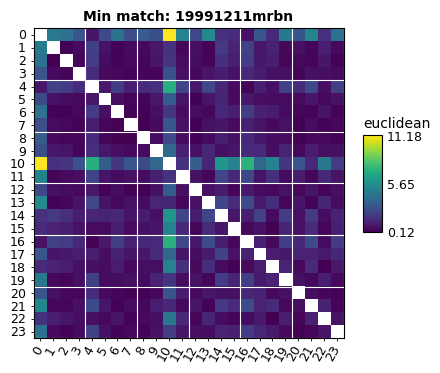

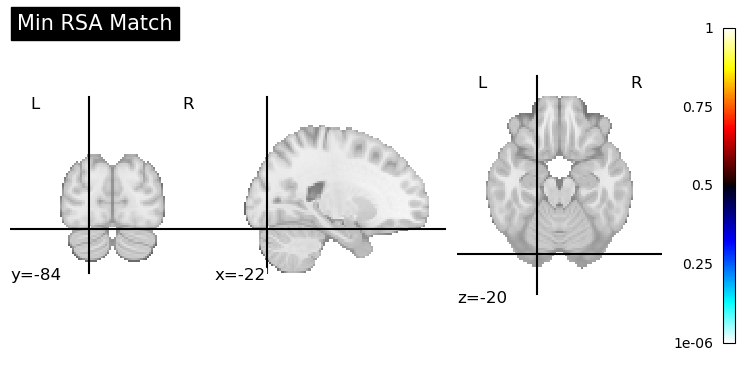

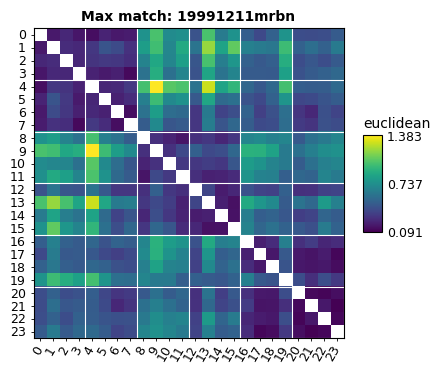

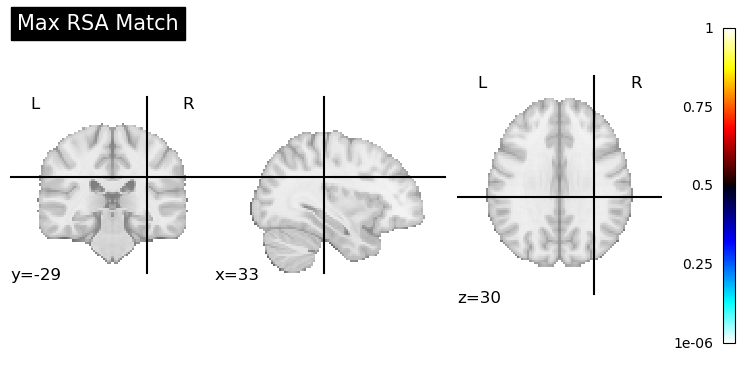

In [21]:
config_class_name = 'SensoryConfig_E2' # sensory model
subjectID = '19991211mrbn'
plot_stuff(config_class_name, subjectID, min = True, max = True)


------Configuration Summary ------

We are using the First Level Model: > SM1B < from directory firstLevel_sensory_M1B
24 conditions were defined
Model RDM Type:     suprasensory
RDM Method:         euclidean
RSA Method:         spearman
Searchlights have a radious of > 5 < voxels, with a threshold of > 0.5 <
Mask used: > full brain mask <

----------------------------------

minimum eval score: -0.08338955448538128 at voxel 89340 (index 21865)
maximum eval score: 0.30342509290368536 at voxel 162375 (index 61508)


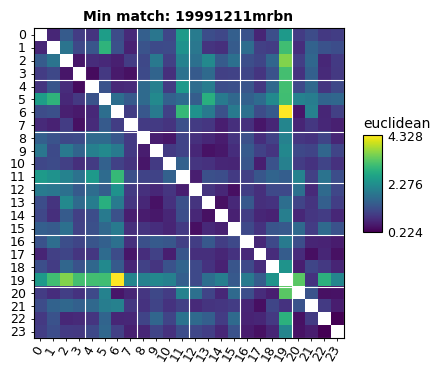

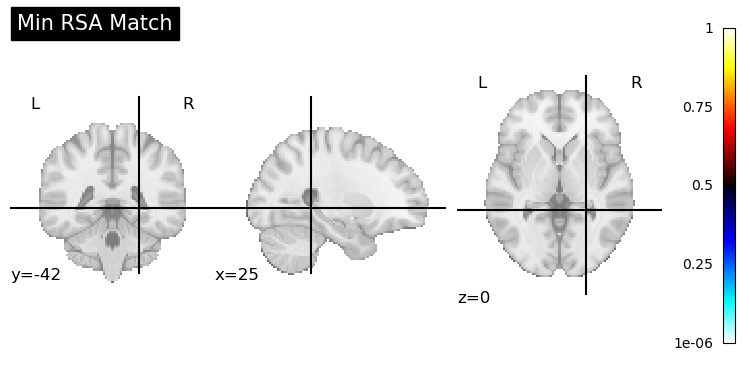

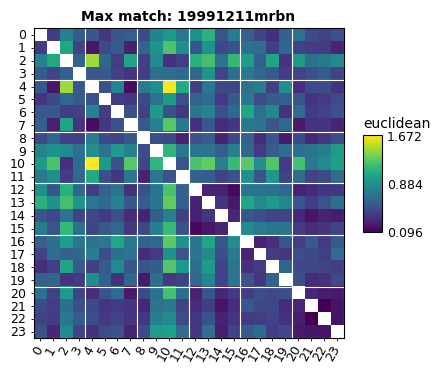

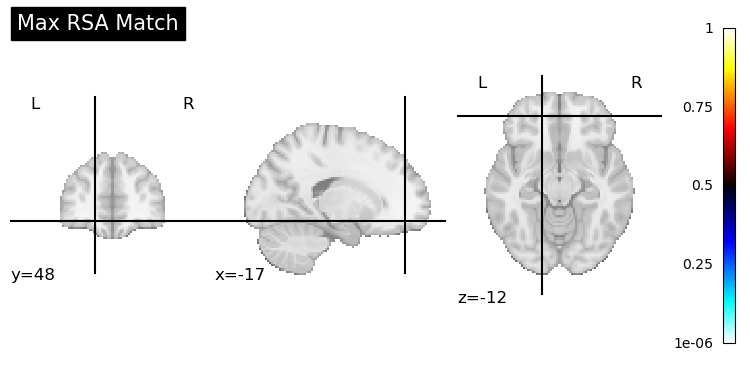

In [22]:
config_class_name = 'SensoryConfig_E4' # suprasensory model
subjectID = '19991211mrbn'
plot_stuff(config_class_name, subjectID, min = True, max = True)


------Configuration Summary ------

We are using the First Level Model: > SM1B < from directory firstLevel_sensory_M1B
24 conditions were defined
Model RDM Type:     suprasensory
RDM Method:         euclidean
RSA Method:         spearman
Searchlights have a radious of > 5 < voxels, with a threshold of > 0.5 <
Mask used: > full brain mask <

----------------------------------

minimum eval score: -0.08967108206124516 at voxel 51829 (index 5773)
maximum eval score: 0.23123304409701798 at voxel 89168 (index 22620)


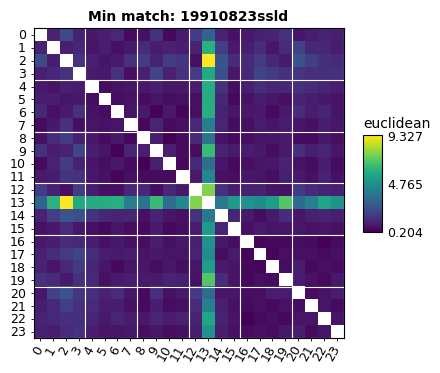

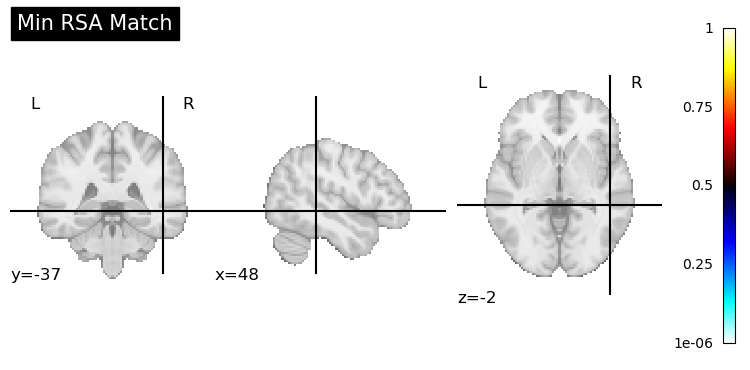

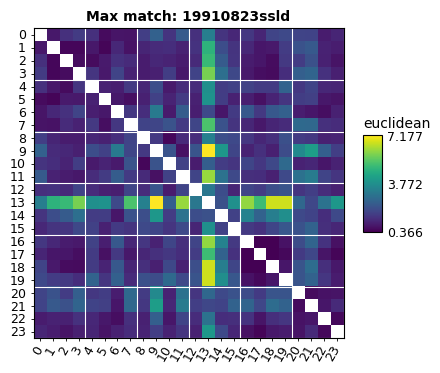

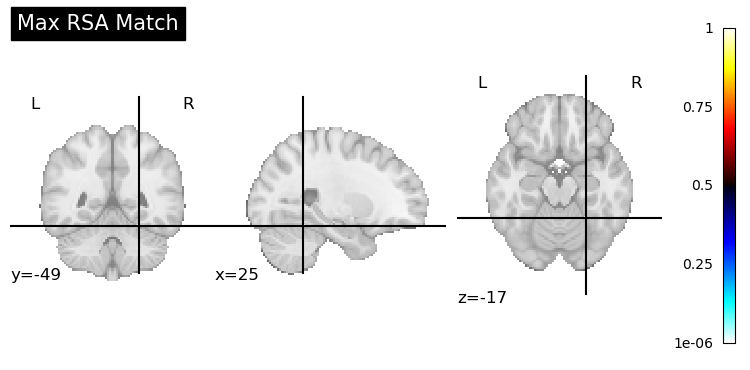

In [23]:
config_class_name = 'SensoryConfig_E4' # suprasensory model
subjectID = '19910823ssld'
plot_stuff(config_class_name, subjectID, min = True, max = True)


------Configuration Summary ------

We are using the First Level Model: > SM1B < from directory firstLevel_sensory_M1B
24 conditions were defined
Model RDM Type:     suprasensory
RDM Method:         euclidean
RSA Method:         spearman
Searchlights have a radious of > 5 < voxels, with a threshold of > 0.5 <
Mask used: > full brain mask <

----------------------------------

minimum eval score: -0.09049041174505348 at voxel 156476 (index 59229)
maximum eval score: 0.13837567993207375 at voxel 43797 (index 3195)


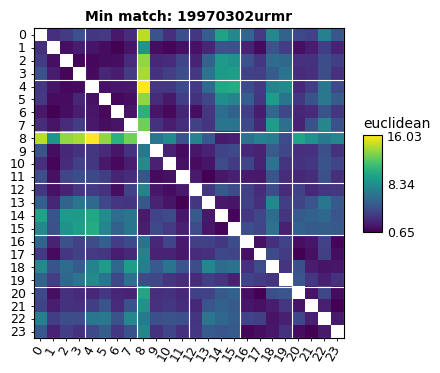

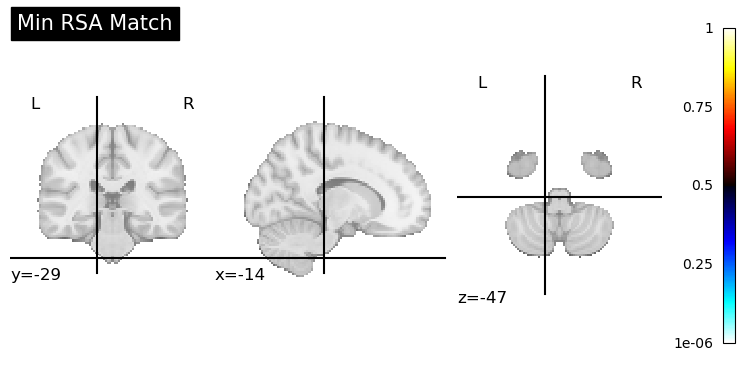

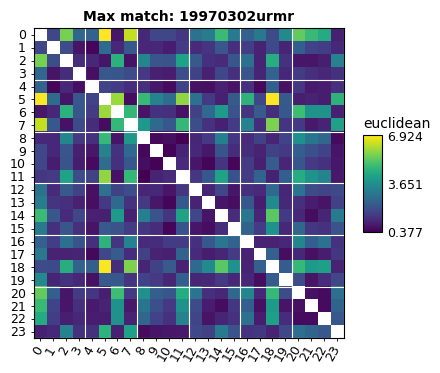

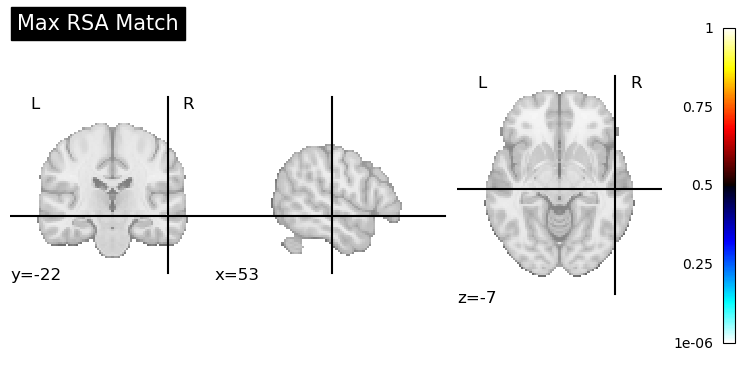

In [24]:
config_class_name = 'SensoryConfig_E4' # suprasensory model
subjectID = '19970302urmr'
plot_stuff(config_class_name, subjectID, min = True, max = True)


------Configuration Summary ------

We are using the First Level Model: > SM1B < from directory firstLevel_sensory_M1B
24 conditions were defined
Model RDM Type:     suprasensory
RDM Method:         euclidean
RSA Method:         spearman
Searchlights have a radious of > 5 < voxels, with a threshold of > 0.5 <
Mask used: > full brain mask <

----------------------------------

minimum eval score: -0.08475510395839517 at voxel 193735 (index 80134)
maximum eval score: 0.2782989826002299 at voxel 30668 (index 525)


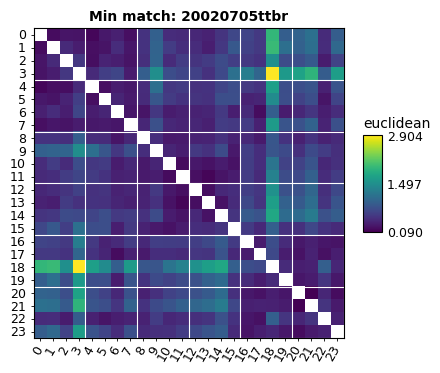

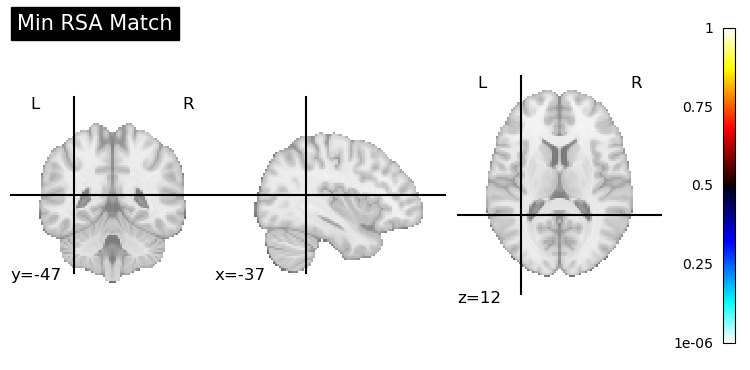

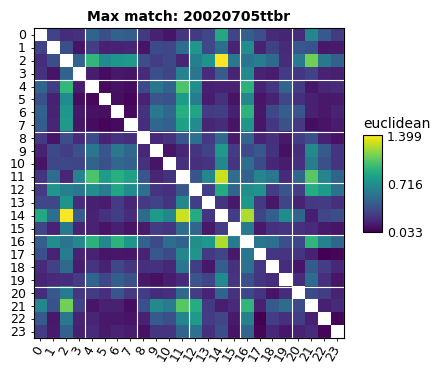

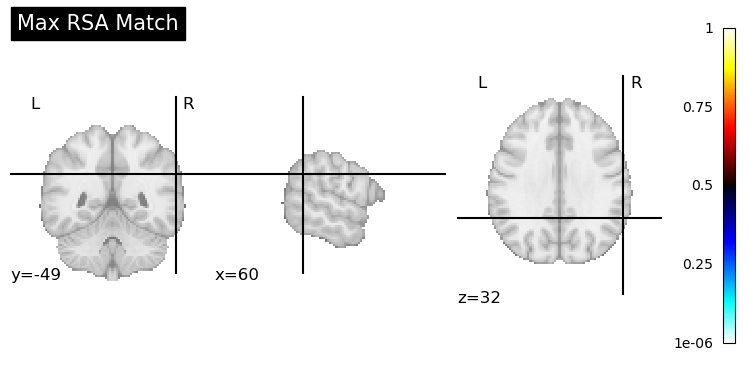

In [25]:
config_class_name = 'SensoryConfig_E4' # suprasensory model
subjectID = '20020705ttbr'
plot_stuff(config_class_name, subjectID, min = True, max = True)

In [ ]:
cfg = load_config_instance(config_class_name, subjectID)
cfg.models_24_file

In [27]:
model = cfg.get_model_RDM()

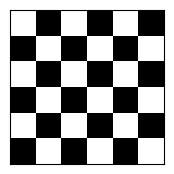

In [29]:
from utils.plots import plot_rdm
plot_rdm(model)

In [34]:
model.predict()


array([0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1.,
       1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0.,
       0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1.,
       1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1.,
       0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1.,
       0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1.,
       1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 1.,
       1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
       0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
       0., 0., 1., 1., 1.

In [35]:
dir(cfg)

['DistPlotFile',
 'RDMmethod',
 'RSAmethod',
 'ResultsPlotFile',
 'SLradius',
 'SLthr',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'configure_paths',
 'dataDir',
 'filePrefix',
 'filePrefix_compiled',
 'filePrefix_fullBrain',
 'filePrefix_partialMasks',
 'firstLevelDir',
 'firstLevelModel',
 'get_mask_path',
 'get_model_RDM',
 'get_outFile_names',
 'maskFile',
 'maskMargin',
 'maskNr',
 'masksDir',
 'modelType',
 'modelsDir',
 'models_24_file',
 'models_6_file',
 'nCond',
 'outDir',
 'outDir_inference',
 'plot1_title',
 'plot2_title',
 'prefix',
 'print_summary',
 'rawDataFolder',
 'resultsPlot_thr',
 'rsaFolder',
 'save_summary',
 'spmDir',
 'sub

In [36]:
cfg.filePrefix

'SL_sensory_E4_SM1B_24Cond_suprasensory_euclidean_spearman_r5_thr0_5'